<a href="https://colab.research.google.com/github/anushkaapandeyy/Kaggle-dataset-practice-notebooks/blob/main/credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
counts = df['Class'].value_counts()
print(counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
df["Class"].value_counts(normalize=True) * 100
#in %

,proportion
Class,
0,99.827251
1,0.172749


In [10]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [11]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


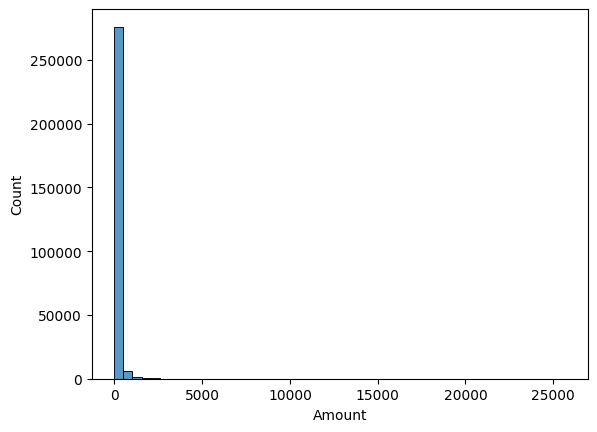

In [12]:
#since x type is numerical, plotting histogram to check it
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Amount'], bins=50)
plt.show()
#long tail to right -> right skewed +ve and likely outliers

The Amount feature is heavily right-skewed with several large-value transactions forming a long right tail. These observations may represent legitimate high-value purchases rather than data errors, so they should be investigated before considering outlier removal.

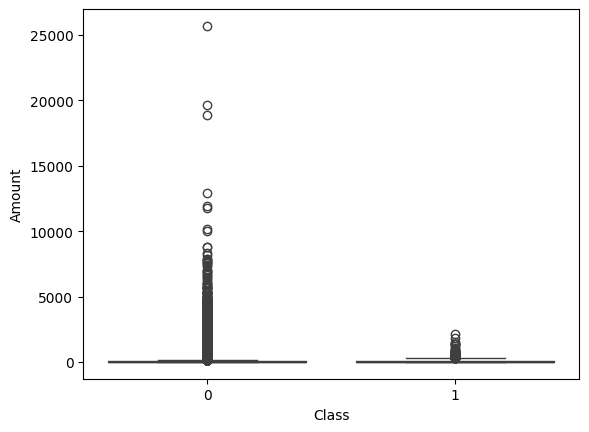

In [13]:
#fraud vs normal -> boxplot
sns.boxplot(x="Class", y="Amount", data=df)
plt.show()


The transaction amount alone does not appear to be a strong indicator of fraud. While fraudulent transactions generally have lower transaction amounts than normal transactions, there is significant overlap between the two classes.

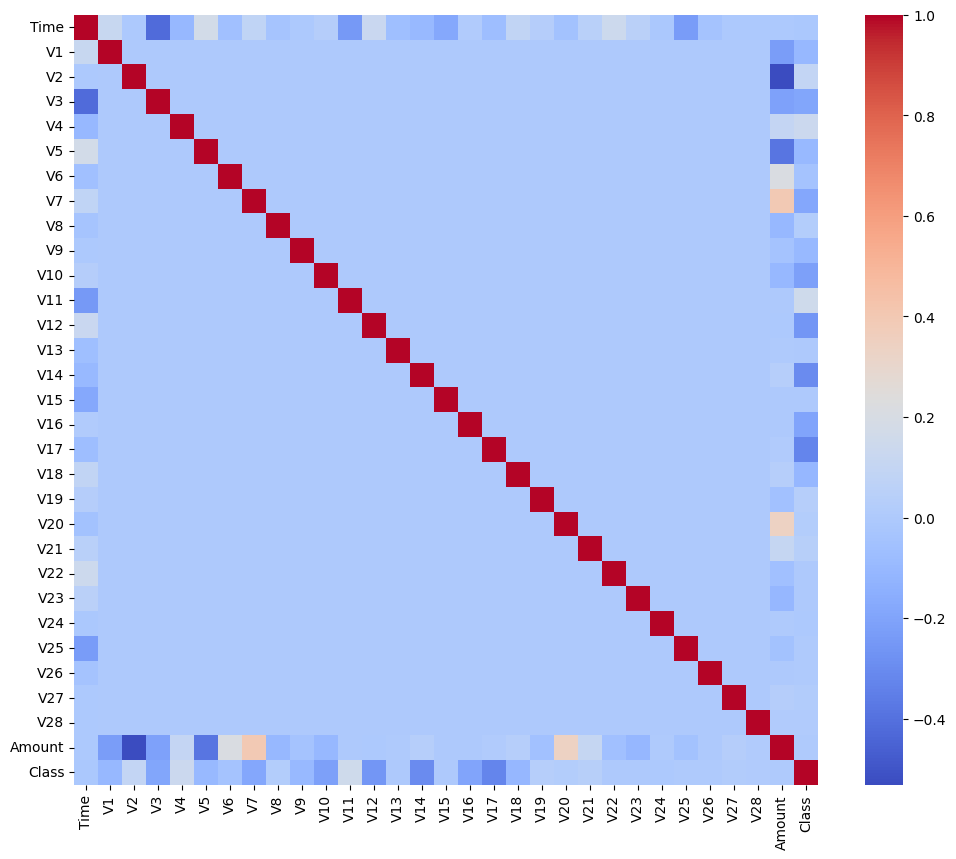

In [17]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()
#no point

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

In [18]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [ ]:
#scaling now time & amount
